In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
spectra_c = []
spectra_dx = []
spectra_sx = []

for i in range(1, 5):
    df = pd.read_csv(f"Spectrum_center_{i}_noreg_gas_exp.csv")
    spectra_c.append(df)

for i in range(1, 5):
    df = pd.read_csv(f"Spectrum_dx_{i}_noreg_gas_exp.csv")
    spectra_dx.append(df)

for i in range(1, 5):
    df = pd.read_csv(f"Spectrum_sx_{i}_noreg_gas_exp.csv")
    spectra_sx.append(df)

In [4]:
spectra_c

[          Name       Flux  Error_flux
 0       Hgamma   1.282840    0.096838
 1        Hbeta   3.285008    0.172276
 2       Halpha  14.409440    0.153349
 3    [SII]6716   2.172780    0.091719
 4    [SII]6731   1.530884    0.066021
 5     HeII4687   0.013355    0.014812
 6      HeI5876   0.487402    0.032487
 7   [OIII]4959   1.579858    0.400062
 8   [OIII]5007   4.739573    0.400062
 9     [OI]6300   0.104842    0.035271
 10    [OI]6364   0.034947    0.035271
 11   [NII]6548   1.032409    0.187000
 12   [NII]6583   3.097226    0.187000,
           Name       Flux  Error_flux
 0       Hgamma   1.258469    0.105350
 1        Hbeta   2.839778    0.101403
 2       Halpha  12.114275    0.166353
 3    [SII]6716   1.821181    0.045274
 4    [SII]6731   1.336868    0.054901
 5     HeII4687   0.000000    0.032684
 6      HeI5876   0.458443    0.050252
 7   [OIII]4959   1.018013    0.282347
 8   [OIII]5007   3.054040    0.282347
 9     [OI]6300   0.134650    0.028782
 10    [OI]6364   0.0448

In [5]:
def Ku03(x):
    # AGN selection based on Kauffman et al. 2003
    # log OIII/Hb > 0.61/(log NII/Ha - 0.05) + 1.3
    return 0.61/(x - 0.05) + 1.3

def Ke01(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.61/(log NII/Ha - 0.47) + 1.19
     return 0.61/(x - 0.47) + 1.19

def S06(x):
    # AGN selection based on Stasinska et al 2006
     # log OIII/Hb > 0.29/(log NII/Ha +0.20) + 0.96
    return 0.29/(x + 0.20) + 0.96

def C10(x):
 # Seyfert–LINER line based on Cid Fernandes et al 2010
    return 1.01*x + 0.48

def Ke01_SII(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.72/(log SII/Ha - 0.32) + 1.3
     return 0.72/(x - 0.32) + 1.3

def Ke06(x):
    #Seyfert–LINER line
    return 1.89* x + 0.76

def error_ratio(err_1, err_2, flux_1, flux_2):
    try:
        e_1 = err_1 / (flux_1 * np.log(10)) if flux_1 != 0 else np.nan
        e_2 = err_2 / (flux_2 * np.log(10)) if flux_2 != 0 else np.nan
        return np.sqrt(e_1**2 + e_2**2)
    except:
        return np.nan

def ratio(spectrum_1):
    flux = spectrum_1['Flux']
    err_flux = spectrum_1['Error_flux']

    OIII = flux[8]
    HB   = flux[1]
    NII  = flux[12]
    HA   = flux[2]
    SII  = flux[3]

    OIII_HB = np.log10(OIII / HB) if OIII > 0 and HB > 0 else np.nan
    NII_HA  = np.log10(NII / HA)  if NII >  0 and HA > 0 else np.nan
    SII_HA  = np.log10(SII / HA)  if SII > 0 and HA > 0 else np.nan

    err_OIII_HB = error_ratio(err_flux[8], err_flux[1], OIII, HB)
    err_NII_HA  = error_ratio(err_flux[12], err_flux[2], NII, HA)
    err_SII_HA  = error_ratio(err_flux[3], err_flux[2], SII, HA)

    return OIII_HB, NII_HA, SII_HA, err_OIII_HB, err_NII_HA, err_SII_HA

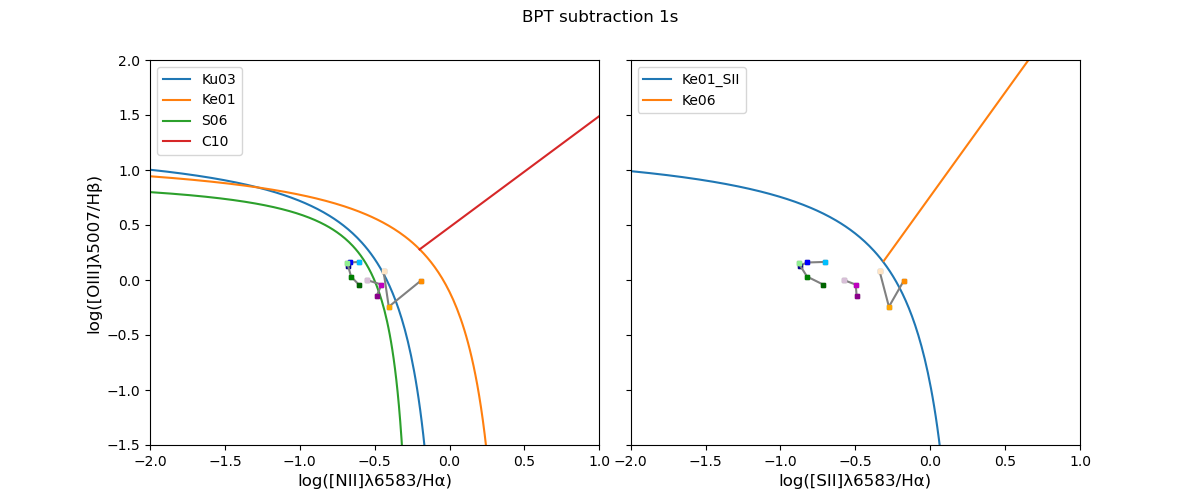

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)
fig.suptitle('BPT subtraction 1s')
x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.2, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03')
ax[0].plot(x1, Ke01(x1), label = 'Ke01')
ax[0].plot(x2, S06(x2), label = 'S06')
ax[0].plot(x3, C10(x3), label = 'C10')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01_SII')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')

NII_HA = np.zeros((4, 3))
OIII_HB = np.zeros((4, 3))
SII_HA = np.zeros((4, 3))
OIII_HB_err = np.zeros((4, 3))
NII_HA_err = np.zeros((4, 3))
SII_HA_err = np.zeros((4, 3))

for i in range(4):
    spectrum_c = spectra_c[i]
    spectrum_dx = spectra_dx[i]
    spectrum_sx = spectra_sx[i]
    oiii_hb_c, nii_ha_c, sii_ha_c, err_oiii_hb_c, err_nii_ha_c, err_sii_ha_c = ratio(spectrum_c)
    oiii_hb_dx, nii_ha_dx, sii_ha_dx, err_oiii_hb_dx, err_nii_ha_dx, err_sii_ha_dx = ratio(spectrum_dx)
    oiii_hb_sx, nii_ha_sx, sii_ha_sx, err_oiii_hb_sx, err_nii_ha_sx, err_sii_ha_sx = ratio(spectrum_sx)
    OIII_HB[i] = [oiii_hb_sx, oiii_hb_c, oiii_hb_dx]
    NII_HA[i] = [nii_ha_sx, nii_ha_c, nii_ha_dx]
    SII_HA[i] = [sii_ha_sx, sii_ha_c, sii_ha_dx]
    OIII_HB_err[i] = [err_oiii_hb_sx, err_oiii_hb_c, err_oiii_hb_dx]
    NII_HA_err[i] = [err_nii_ha_sx, err_nii_ha_c, err_nii_ha_dx]
    SII_HA_err[i] = [err_sii_ha_sx, err_sii_ha_c, err_sii_ha_dx]

colors1 = ['deepskyblue', 'lightgreen', 'thistle', 'bisque']
colors2 = ['blue', 'green', 'm', 'orange']
colors3 = ['darkblue', 'darkgreen', 'darkmagenta', 'darkorange']

for j in range(4): 
    # Plotta tutti e 3 i punti insieme per ogni colore
    ax[0].plot([NII_HA[j][0], NII_HA[j][1], NII_HA[j][2]], 
               [OIII_HB[j][0], OIII_HB[j][1], OIII_HB[j][2]], 
               color='gray', marker='s', linestyle='-', markersize=3)
    
    ax[0].plot(NII_HA[j][0], OIII_HB[j][0], color=colors1[j], marker='s', markersize=3)
    ax[0].plot(NII_HA[j][1], OIII_HB[j][1], color=colors2[j], marker='s', markersize=3)
    ax[0].plot(NII_HA[j][2], OIII_HB[j][2], color=colors3[j], marker='s', markersize=3)
    
    ax[1].plot([SII_HA[j][0], SII_HA[j][1], SII_HA[j][2]], 
               [OIII_HB[j][0], OIII_HB[j][1], OIII_HB[j][2]], 
               color= 'gray', marker='s', linestyle='-', markersize=3)
    ax[1].plot(SII_HA[j][0], OIII_HB[j][0], color=colors1[j], marker='s', markersize=3)
    ax[1].plot(SII_HA[j][1], OIII_HB[j][1], color=colors2[j], marker='s', markersize=3)
    ax[1].plot(SII_HA[j][2], OIII_HB[j][2], color=colors3[j], marker='s', markersize=3)

ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6583/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.07)
plt.savefig('BPT_grad.png', bbox_inches='tight')    
